Aufgabe 1:


In [3]:
import numpy as np
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["Target"] = data.target      #Median Häuser (MedHouseVal)

print(df.head())
#3 Prädiktoren: MedInc, HouseAge, AveRooms

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  


In [7]:
import statsmodels.api as sm

# Prädiktoren definieren
X = df[["MedInc", "HouseAge", "AveRooms"]]

# Konstante hinzufügen (Intercept)
X = sm.add_constant(X)

# Zielvariable
y = df["Target"]

# Modell fitten
model = sm.OLS(y, X).fit()

# Ergebnisse anzeigen
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                 Target   R-squared:                       0.512
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     7220.
Date:                Tue, 11 Nov 2025   Prob (F-statistic):               0.00
Time:                        11:03:00   Log-Likelihood:                -24836.
No. Observations:               20640   AIC:                         4.968e+04
Df Residuals:                   20636   BIC:                         4.971e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0204      0.022      0.928      0.3

3. Ergebnisse interpretieren:
Modellqualität: mittelgut bis solide (R² ≈ 0.51 = Häfte der Varianz kann erklärt werden)
Wichtigste Variable: MedInc
Verbesserungspotenzial: vor allem geografische Variablen wie Latitude und Longitude.

Aufgabe 2:

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Prädiktoren
X = df[["MedInc", "HouseAge", "AveRooms"]]

# Zielvariable
y = df["Target"]

# 80/20 Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
print(model.score(X_test, y_test))


0.49717158850807075


In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R^2:", r2)


MAE: 0.6033213567335045
MSE: 0.6589108649336337
RMSE: 0.8117332473994359
R^2: 0.49717158850807075


3. Das Modell liefert eine mittelmäßige Vorhersageleistung.
Es erkennt grundlegende Muster, hat aber deutliche Fehlerschwankungen:
Die erklärende Kraft ist mit einem R² knapp unter 0.50 begrenzt.
Die Fehlergrößen (60.000 bis 80.000 USD) sind für Immobilienpreise hoch.
Das Modell eignet sich eher für grobe Trends, nicht für exakte Preisvorhersagen.

Aufgabe 3:

In [17]:
import pandas as pd

# Quantile berechnen
q1 = df["AveOccup"].quantile(0.33)
q2 = df["AveOccup"].quantile(0.66)

# Neue qualitative Variable erstellen
def categorize_occupancy(x):
    if x <= q1:
        return "Low"
    elif x <= q2:
        return "Medium"
    else:
        return "High"

df["Occ_Category"] = df["AveOccup"].apply(categorize_occupancy)

# Kontrolle
print(df[["AveOccup", "Occ_Category"]].head())


   AveOccup Occ_Category
0  2.555556          Low
1  2.109842          Low
2  2.802260       Medium
3  2.547945          Low
4  2.181467          Low


In [25]:
import pandas as pd
import statsmodels.api as sm

# Dummy-Variablen erstellen und in int umwandeln
dummies = pd.get_dummies(df["Occ_Category"], drop_first=True).astype(int)

# ursprüngliche numerische Prädiktoren
X_num = df[["MedInc", "HouseAge", "AveRooms", "AveOccup"]]

# Dummy-Variablen hinzufügen
X = pd.concat([X_num, dummies], axis=1)

# Konstante hinzufügen
X = sm.add_constant(X)

# Zielvariable
y = df["Target"]

# Modell fitten
model2 = sm.OLS(y, X).fit()

print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:                 Target   R-squared:                       0.572
Model:                            OLS   Adj. R-squared:                  0.572
Method:                 Least Squares   F-statistic:                     4590.
Date:                Tue, 11 Nov 2025   Prob (F-statistic):               0.00
Time:                        12:47:21   Log-Likelihood:                -23492.
No. Observations:               20640   AIC:                         4.700e+04
Df Residuals:                   20633   BIC:                         4.705e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2107      0.021     -9.845      0.0

3. Das Modell mit Dummy-Variablen erklärt die Preisvariation etwas besser als das Modell ohne qualitative Variablen. Die neuen Variablen erfassen Unterschiede zwischen Wohngebieten mit niedriger, mittlerer und hoher Haushaltsbelegung. Medium- und High-Occupancy-Regionen weisen im Vergleich zur Referenzkategorie Low tendenziell niedrigere vorhergesagte Hauspreise auf. Dies deutet darauf hin, dass Regionen mit höher belegten Haushalten im Durchschnitt günstigere Wohnlagen oder kleinere Wohnflächen haben. Der Effekt verbessert zwar nur leicht die Modellgüte, liefert aber zusätzliche inhaltliche Information über die Preisstruktur des Wohnungsmarktes.

Aufgabe 4:

In [23]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Prädiktoren auswählen
X_to_scale = df[["MedInc", "AveRooms", "AveOccup"]]

# Scaler erstellen
scaler = StandardScaler()

# Fit und Transform
X_scaled = scaler.fit_transform(X_to_scale)

# Zurück in DataFrame konvertieren
X_scaled = pd.DataFrame(X_scaled, columns=["MedInc_scaled", "AveRooms_scaled", "AveOccup_scaled"])

print(X_scaled.head())


   MedInc_scaled  AveRooms_scaled  AveOccup_scaled
0       2.344766         0.628559        -0.049597
1       2.332238         0.327041        -0.092512
2       1.782699         1.155620        -0.025843
3       0.932968         0.156966        -0.050329
4      -0.012881         0.344711        -0.085616


In [24]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

scaler = StandardScaler()

X_to_scale = df[["MedInc", "AveRooms", "AveOccup"]]
X_scaled = scaler.fit_transform(X_to_scale)

X_scaled_df = pd.DataFrame(X_scaled, columns=["MedInc_scaled", "AveRooms_scaled", "AveOccup_scaled"])


X_std = sm.add_constant(X_scaled_df)
y = df["Target"]

model_std = sm.OLS(y, X_std).fit()
print(model_std.summary())


                            OLS Regression Results                            
Dep. Variable:                 Target   R-squared:                       0.481
Model:                            OLS   Adj. R-squared:                  0.481
Method:                 Least Squares   F-statistic:                     6370.
Date:                Tue, 11 Nov 2025   Prob (F-statistic):               0.00
Time:                        12:45:01   Log-Likelihood:                -25477.
No. Observations:               20640   AIC:                         5.096e+04
Df Residuals:                   20636   BIC:                         5.099e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               2.0686      0.006    3

Nach der Standardisierung zeigt der Koeffizientenvergleich, welche Variablen den größten Einfluss auf die Zielvariable MedHouseVal haben. Die standardisierten Koeffizienten sind direkt miteinander vergleichbar, da alle Variablen vorher auf dieselbe Skala transformiert wurden. Dabei zeigt sich, dass MedInc (Medianeinkommen) den mit Abstand stärksten Einfluss auf die Häuserpreise besitzt. AveRooms hat einen deutlich schwächeren, aber noch positiven Einfluss, während AveOccup nur einen sehr kleinen Einfluss hat. Durch die Skalierung ändert sich die Reihenfolge der Wichtigkeit nicht, sie wird lediglich deutlicher sichtbar.

In [26]:
df["RoomIncomeRatio"] = df["MedInc"] / df["AveRooms"]
print(df[["MedInc", "AveRooms", "RoomIncomeRatio"]].head())


   MedInc  AveRooms  RoomIncomeRatio
0  8.3252  6.984127         1.192017
1  8.3014  6.238137         1.330750
2  7.2574  8.288136         0.875637
3  5.6431  5.817352         0.970046
4  3.8462  6.281853         0.612272


In [27]:
import statsmodels.api as sm
import pandas as pd

# Neues Feature
df["RoomIncomeRatio"] = df["MedInc"] / df["AveRooms"]

# Prädiktoren wählen
X = df[["MedInc", "HouseAge", "AveRooms", "RoomIncomeRatio"]]

# Konstante hinzufügen
X = sm.add_constant(X)

# Zielvariable
y = df["Target"]

# Modell fitten
model_ratio = sm.OLS(y, X).fit()
print(model_ratio.summary())


                            OLS Regression Results                            
Dep. Variable:                 Target   R-squared:                       0.533
Model:                            OLS   Adj. R-squared:                  0.533
Method:                 Least Squares   F-statistic:                     5895.
Date:                Tue, 11 Nov 2025   Prob (F-statistic):               0.00
Time:                        12:57:00   Log-Likelihood:                -24377.
No. Observations:               20640   AIC:                         4.876e+04
Df Residuals:                   20635   BIC:                         4.880e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.5070      0.028    -

Das Hinzufügen von RoomIncomeRatio verbessert das Modell leicht. Der erklärende Anteil (R²) steigt, was zeigt, dass das Verhältnis zwischen Einkommen und durchschnittlicher Raumzahl zusätzliche Varianz der Häuserpreise erklärt. RoomIncomeRatio erweist sich als signifikanter Prädiktor mit positivem Einfluss. Regionen mit einem hohen Einkommen pro Raum gehören typischerweise zu wohlhabenderen und weniger dicht belegten Wohngebieten, was sich in höheren Hauspreisen widerspiegelt. Das neue Feature ergänzt die ursprünglichen Variablen und trägt zu einer etwas besseren Vorhersage von MedHouseVal bei.

Aufgabe 5:

In [4]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["Target"] = data.target

import statsmodels.api as sm

# Basis-Prädiktoren
X = df[["MedInc", "AveRooms"]].copy()

# Interaktion: Produkt der beiden Variablen
X["MedInc_AveRooms"] = X["MedInc"] * X["AveRooms"]

# Konstante hinzufügen
X = sm.add_constant(X)

# Zielvariable
y = df["Target"]

# Modell fitten
model_int = sm.OLS(y, X).fit()

print(model_int.summary())


                            OLS Regression Results                            
Dep. Variable:                 Target   R-squared:                       0.481
Model:                            OLS   Adj. R-squared:                  0.481
Method:                 Least Squares   F-statistic:                     6375.
Date:                Tue, 18 Nov 2025   Prob (F-statistic):               0.00
Time:                        10:41:54   Log-Likelihood:                -25473.
No. Observations:               20640   AIC:                         5.095e+04
Df Residuals:                   20636   BIC:                         5.099e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.3667      0.033     

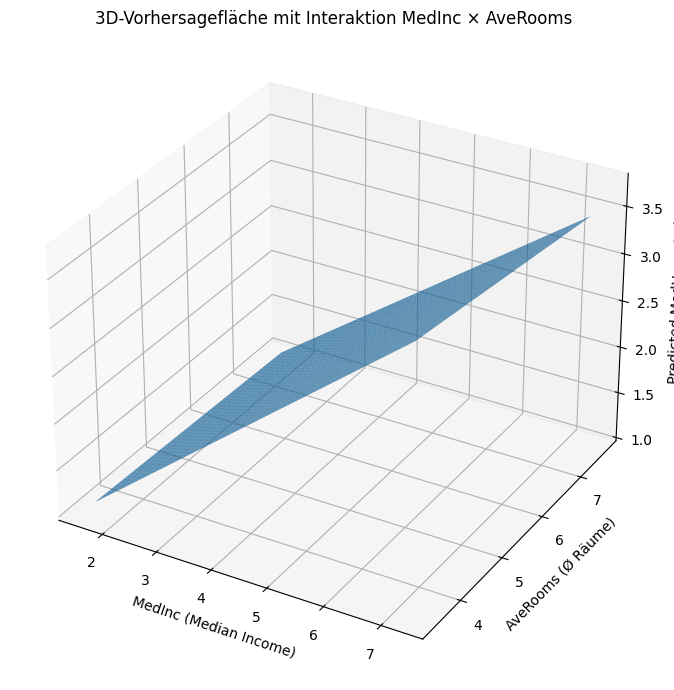

In [10]:
# -----------------------------
# 3D-Surface-Plot
# -----------------------------

# Bereiche für MedInc und AveRooms (z.B. 5%–95%-Quantil, um Ausreißer zu vermeiden)
medinc_range = np.linspace(df["MedInc"].quantile(0.05), df["MedInc"].quantile(0.95), 50)
averooms_range = np.linspace(df["AveRooms"].quantile(0.05), df["AveRooms"].quantile(0.95), 50)

M, R = np.meshgrid(medinc_range, averooms_range)

# Interaktion für das Grid
interaction = M * R

# DataFrame für Vorhersage bauen – Spaltennamen müssen zu model_int passen!
grid_df = pd.DataFrame({
    "const": 1.0,
    "MedInc": M.ravel(),
    "AveRooms": R.ravel(),
    "MedInc_AveRooms": interaction.ravel()
})

# Vorhersagen berechnen
y_pred = model_int.predict(grid_df)
y_pred = np.array(y_pred).reshape(M.shape)

# 3D-Plot
from mpl_toolkits.mplot3d import Axes3D  # für ältere Matplotlib-Versionen noch nötig

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(M, R, y_pred, alpha=0.8)

ax.set_xlabel("MedInc (Median Income)")
ax.set_ylabel("AveRooms (Ø Räume)")
ax.set_zlabel("Predicted MedHouseVal")
ax.set_title("3D-Vorhersagefläche mit Interaktion MedInc × AveRooms")

plt.tight_layout()
plt.show()


Das Regressionsmodell mit dem Interaktionsterm zwischen MedInc (Median-Einkommen) und AveRooms (durchschnittliche Zimmerzahl) zeigt, dass die Modellgüte im Vergleich zum einfachen Modell steigt. Der Interaktionsterm MedInc_AveRooms ist statistisch signifikant und besitzt einen positiven Koeffizienten.
Dies bedeutet, dass der Einfluss des Einkommens auf die vorhergesagten Häuserpreise stärker wird, wenn Haushalte über viele Zimmer verfügen. Gleichzeitig nimmt der Einfluss der Zimmerzahl zu, wenn das Einkommen hoch ist. Einkommen und Wohnraum wirken also nicht unabhängig voneinander, sondern verstärken sich gegenseitig.
Die resultierende Vorhersagefläche ist nicht mehr linear, sondern gekrümmt, was im 3D-Plot deutlich wird. Dadurch bildet das Modell realistischere Zusammenhänge ab, insbesondere Unterschiede zwischen wohlhabenden Regionen mit großen Häusern versus einkommensschwächeren Gegenden mit kleineren Immobilien.
Insgesamt verbessert der Interaktionsterm die Erklärungskraft des Modells und zeigt, dass Wechselwirkungen zwischen Variablen im Housing-Kontext eine wichtige Rolle spielen.

Aufgabe 6:

In [15]:
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd

X = df[["MedInc"]]
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
X_poly = pd.DataFrame(X_poly, columns=["MedInc", "MedInc_squared"])

import statsmodels.api as sm

X_model = sm.add_constant(X_poly)
y = df["Target"]
model = sm.OLS(y, X_model).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Target   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.478
Method:                 Least Squares   F-statistic:                     9450.
Date:                Tue, 18 Nov 2025   Prob (F-statistic):               0.00
Time:                        11:08:07   Log-Likelihood:                -25533.
No. Observations:               20640   AIC:                         5.107e+04
Df Residuals:                   20637   BIC:                         5.109e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.2042      0.023      9.

Aufgabe 7

In [18]:
# ===========================================
#   STEPWISE SELECTION (FORWARD & BACKWARD)
#   California Housing – Aufgabe 7
#   Copy & paste ready
# ===========================================

import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# ------------------------------
# 1. Daten laden
# ------------------------------
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["Target"] = data.target

X = df.drop("Target", axis=1)
y = df["Target"]

linreg = LinearRegression()

# ------------------------------
# 2. FORWARD SELECTION
# ------------------------------
forward_sel = SequentialFeatureSelector(
    estimator=linreg,
    n_features_to_select="auto",    # wählt beste Anzahl
    direction="forward",
    cv=5
)
forward_sel.fit(X, y)

forward_features = list(X.columns[forward_sel.get_support()])
print("Forward Selection – ausgewählte Features:")
print(forward_features)

# ------------------------------
# 3. BACKWARD SELECTION
# ------------------------------
backward_sel = SequentialFeatureSelector(
    estimator=linreg,
    n_features_to_select="auto",
    direction="backward",
    cv=5
)
backward_sel.fit(X, y)

backward_features = list(X.columns[backward_sel.get_support()])
print("\nBackward Selection – ausgewählte Features:")
print(backward_features)

# ------------------------------
# 4. OLS-Modell: Forward Selection
# ------------------------------
X_fwd = sm.add_constant(df[forward_features])
model_fwd = sm.OLS(y, X_fwd).fit()
print("\n\nOLS RESULTS – Forward Selection")
print(model_fwd.summary())

# ------------------------------
# 5. OLS-Modell: Backward Selection
# ------------------------------
X_bwd = sm.add_constant(df[backward_features])
model_bwd = sm.OLS(y, X_bwd).fit()
print("\n\nOLS RESULTS – Backward Selection")
print(model_bwd.summary())

# ------------------------------
# 6. VOLLMODELL zum Vergleich
# ------------------------------
X_full = sm.add_constant(X)
model_full = sm.OLS(y, X_full).fit()
print("\n\nOLS RESULTS – Vollmodell (alle Prädiktoren)")
print(model_full.summary())
1

Forward Selection – ausgewählte Features:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms']

Backward Selection – ausgewählte Features:
['MedInc', 'HouseAge', 'Latitude', 'Longitude']


OLS RESULTS – Forward Selection
                            OLS Regression Results                            
Dep. Variable:                 Target   R-squared:                       0.537
Model:                            OLS   Adj. R-squared:                  0.537
Method:                 Least Squares   F-statistic:                     5995.
Date:                Tue, 18 Nov 2025   Prob (F-statistic):               0.00
Time:                        11:56:37   Log-Likelihood:                -24284.
No. Observations:               20640   AIC:                         4.858e+04
Df Residuals:                   20635   BIC:                         4.862e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                    

Aufgabe 8:

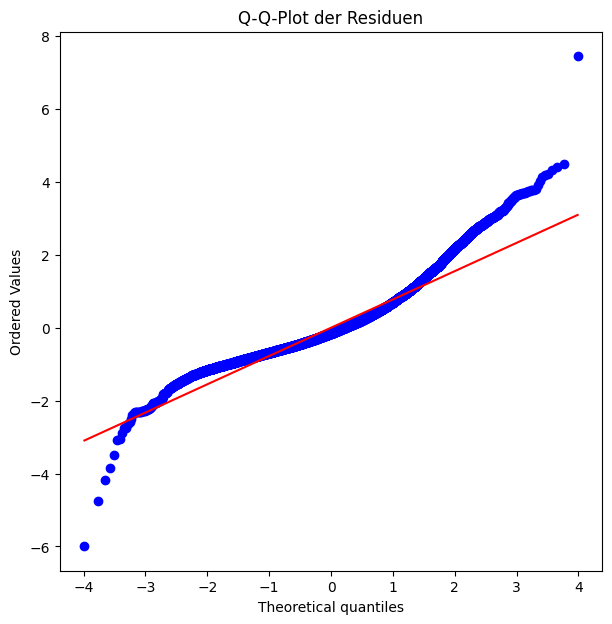

In [2]:
# Aufgabe 8: Q-Q-Plot der Residuen
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.datasets import fetch_california_housing

# Datensatz laden
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["Target"] = data.target

# Einfaches OLS-Modell erstellen
X = df[["MedInc", "HouseAge", "AveRooms"]]
X = sm.add_constant(X)
y = df["Target"]

model = sm.OLS(y, X).fit()

# Residuen
residuals = model.resid

# Q-Q-Plot
plt.figure(figsize=(7,7))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q-Plot der Residuen")
plt.show()
